In [1]:
import numpy as np
import pandas as pd
features = np.load('data/noA_features.npy')
df = pd.read_csv('data/noA.csv', index_col=0)

In [2]:
df

,audio_path,machine,year,domain,attribute,label
0,/mnt/storage1/asd/2025/data/ToyTrain/train/sec...,ToyTrain,2025,source,noAttribute,ToyTrain_source_noAttribute
1,/mnt/storage1/asd/2025/data/ToyTrain/train/sec...,ToyTrain,2025,source,noAttribute,ToyTrain_source_noAttribute
2,/mnt/storage1/asd/2025/data/ToyTrain/train/sec...,ToyTrain,2025,source,noAttribute,ToyTrain_source_noAttribute
3,/mnt/storage1/asd/2025/data/ToyTrain/train/sec...,ToyTrain,2025,source,noAttribute,ToyTrain_source_noAttribute
4,/mnt/storage1/asd/2025/data/ToyTrain/train/sec...,ToyTrain,2025,source,noAttribute,ToyTrain_source_noAttribute
...,...,...,...,...,...,...
6995,/mnt/storage1/asd/2025/data/ToyPet/train/secti...,ToyPet,2025,target,noAttribute,ToyPet_target
6996,/mnt/storage1/asd/2025/data/ToyPet/train/secti...,ToyPet,2025,target,noAttribute,ToyPet_target
6997,/mnt/storage1/asd/2025/data/ToyPet/train/secti...,ToyPet,2025,target,noAttribute,ToyPet_target
6998,/mnt/storage1/asd/2025/data/ToyPet/train/secti...,ToyPet,2025,target,noAttribute,ToyPet_target


In [3]:
features.shape, features 

((7000, 512),
 array([[ 0.12914634, -0.61408263, -0.30108058, ...,  0.09688346,
          0.00838936, -0.10306031],
        [-0.04598417, -0.44946292, -0.0193436 , ...,  0.14961201,
         -0.24129213, -0.44475037],
        [-0.40555665, -0.34423468, -0.30318046, ..., -1.290582  ,
          0.8941541 , -0.442133  ],
        ...,
        [-0.01825409, -0.4434579 , -0.16561708, ...,  0.08860902,
         -0.22134484,  0.3123457 ],
        [-0.45333797,  0.01134768, -0.07666092, ...,  0.04394519,
          0.06489855,  0.09460399],
        [ 0.00794711, -0.4094737 , -1.2905841 , ...,  0.4761809 ,
          0.44604668, -0.34945667]], dtype=float32))

In [4]:
toytrain = features[:1000]
slider = features[1000:2000]
bearing = features[2000:3000]
autotrash = features[3000:4000]
polisher = features[4000:5000]
screwfeeder = features[5000:6000]
toypet = features[6000:7000]

In [5]:
import numpy as np
import umap
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.colors as mcolors
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.utils.deprecation")
matplotlib.rcParams['axes.unicode_minus'] = False

def dend(features, machine, n, y, r):
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.0, n_components=2, random_state=42, n_jobs=1)
    features_2d = reducer.fit_transform(features)

    Z = linkage(features_2d, method='ward')

    # 다양한 k에 대한 실루엣 점수 계산
    silhouette_scores = []
    k_range = range(max(r[0], 2), r[1])
    for k in k_range:
        labels_k = fcluster(Z, t=k, criterion='maxclust')
        score = silhouette_score(features_2d, labels_k)
        silhouette_scores.append(score)

    # 최적 k 찾기
    k_max = k_range[np.argmax(silhouette_scores)]
    max_score = max(silhouette_scores)

    labels = fcluster(Z, t=n, criterion='maxclust')

    # 실루엣 점수 계산
    silhouette_avg = silhouette_score(features_2d, labels)
    sample_silhouette_values = silhouette_samples(features_2d, labels)
    n_clusters = len(np.unique(labels))

    # 세 개의 서브플롯 생성
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

    # 덴드로그램 플롯
    dendrogram(Z, ax=ax1)
    ax1.set_title(f'{machine} Dendrogram')
    ax1.set_xlabel('Sample Index')
    ax1.set_ylabel('Distance')
    ax1.axhline(y, color='black')

    # UMAP 플롯
    scatter = ax2.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, cmap='Spectral')
    ax2.set_title(f'{machine} UMAP Projection')
    ax2.set_xlabel('UMAP 1')
    ax2.set_ylabel('UMAP 2')
    plt.colorbar(scatter, ax=ax2, label='Cluster')

    # 실루엣 점수 대 k 플롯
    ax3.plot(k_range, silhouette_scores, marker='o')
    ax3.axvline(x=k_max, color='red', linestyle='--')
    ax3.set_title(f'Silhouette Score vs. Number of Clusters\nOptimal k = {k_max} (score: {max_score:.2f})')
    ax3.set_xlabel('Number of Clusters (k)')
    ax3.set_ylabel('Average Silhouette Score')

    plt.tight_layout()

/home/user/anaconda3/envs/HJ_audio/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


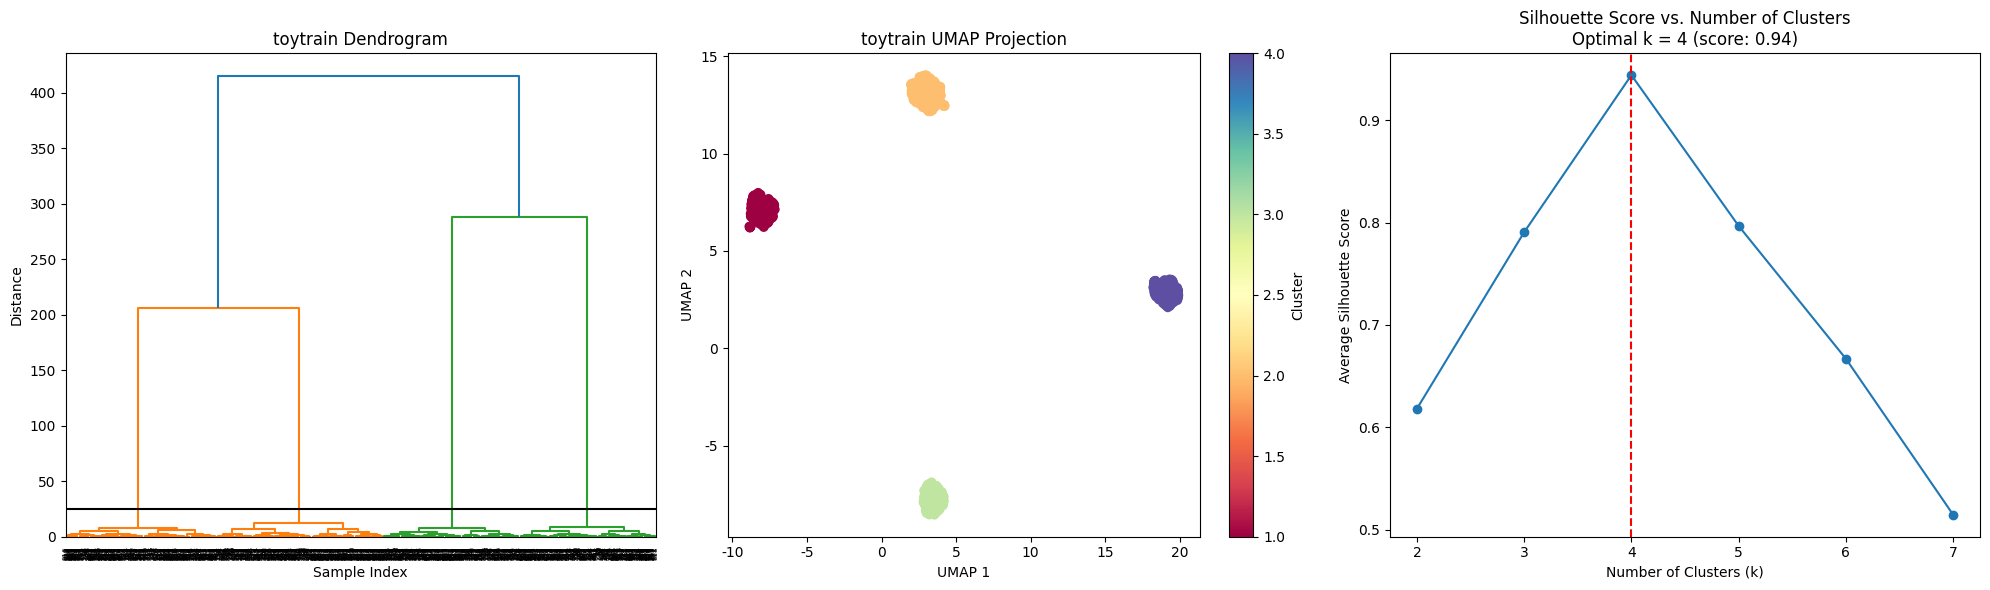

In [6]:
dend(toytrain, 'toytrain', 4, 25, [2, 8])

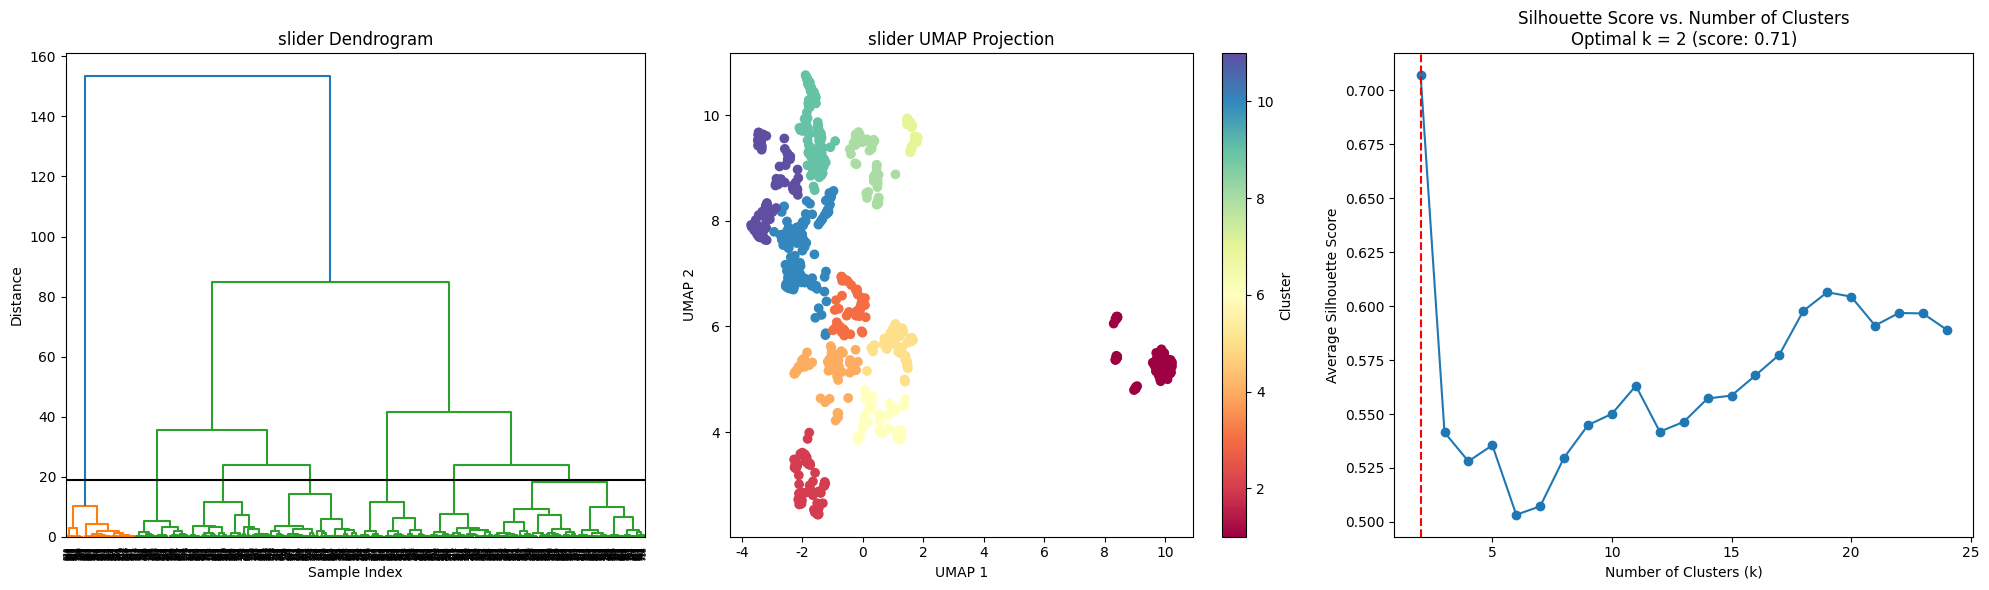

In [7]:
dend(slider, 'slider', 11, 19, [2, 25])

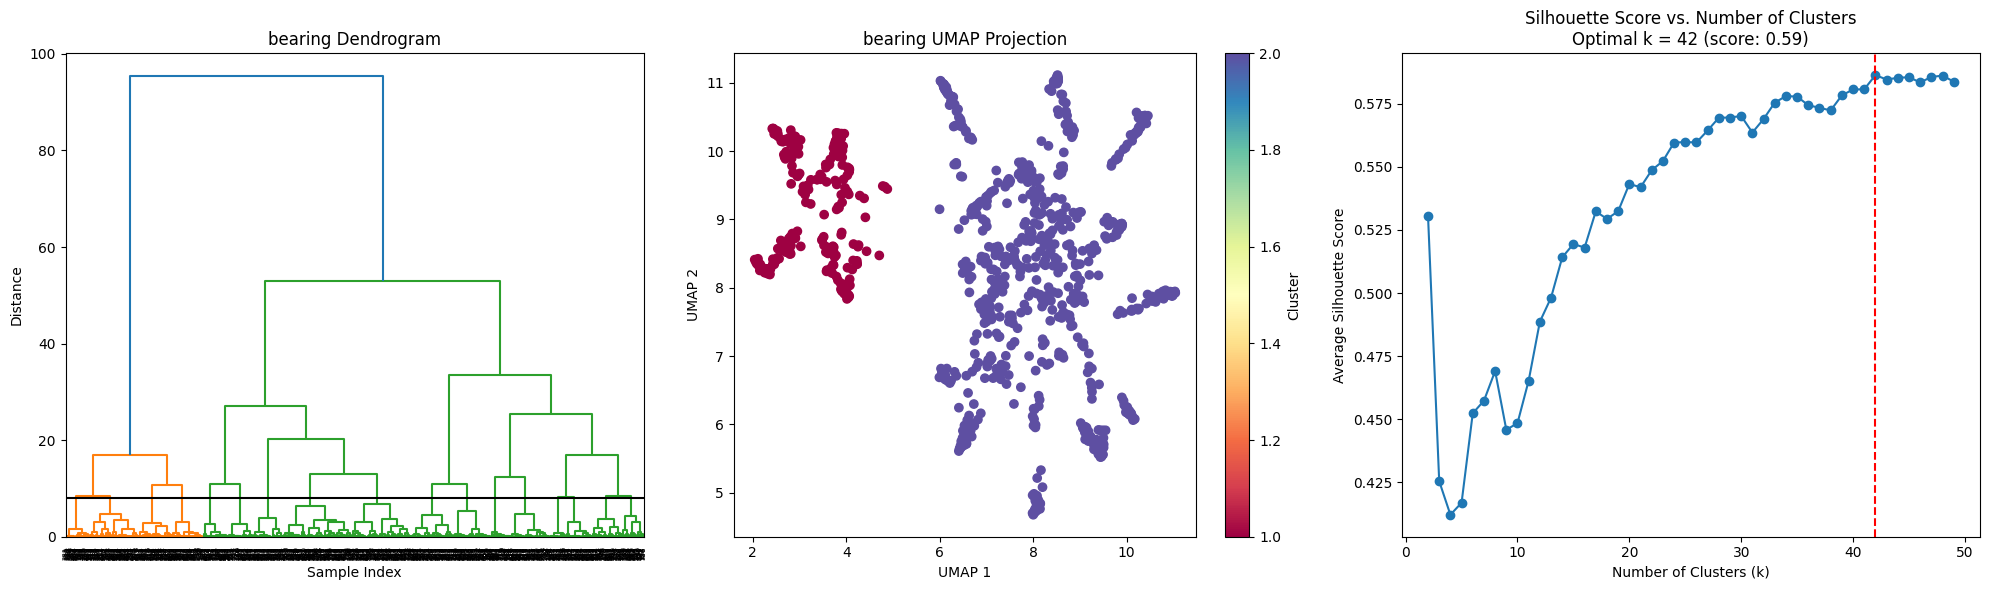

In [14]:
dend(bearing, 'bearing', 2, 8, [2, 50])

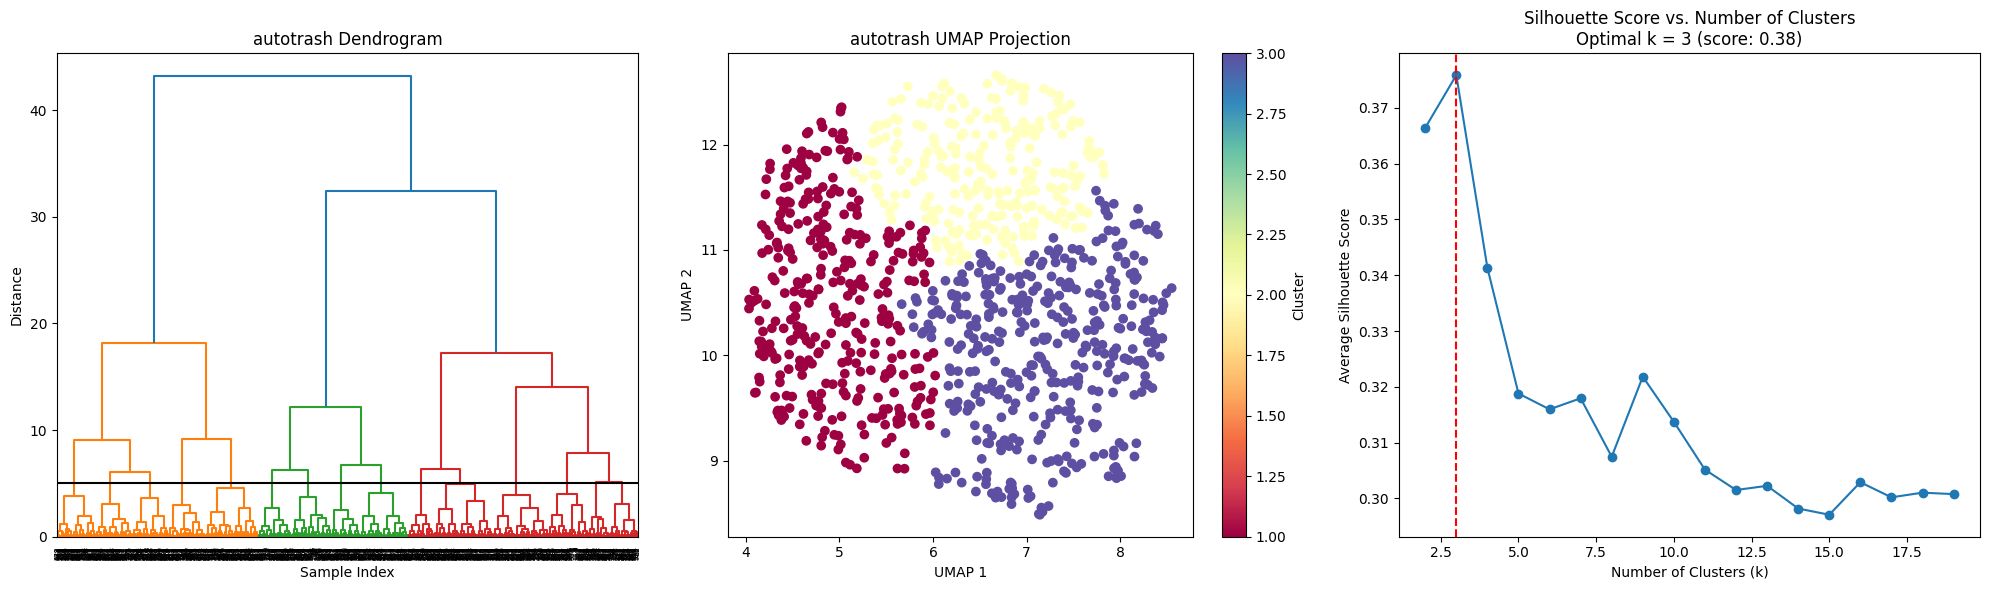

In [9]:
dend(autotrash, 'autotrash', 3, 5, [2, 20])

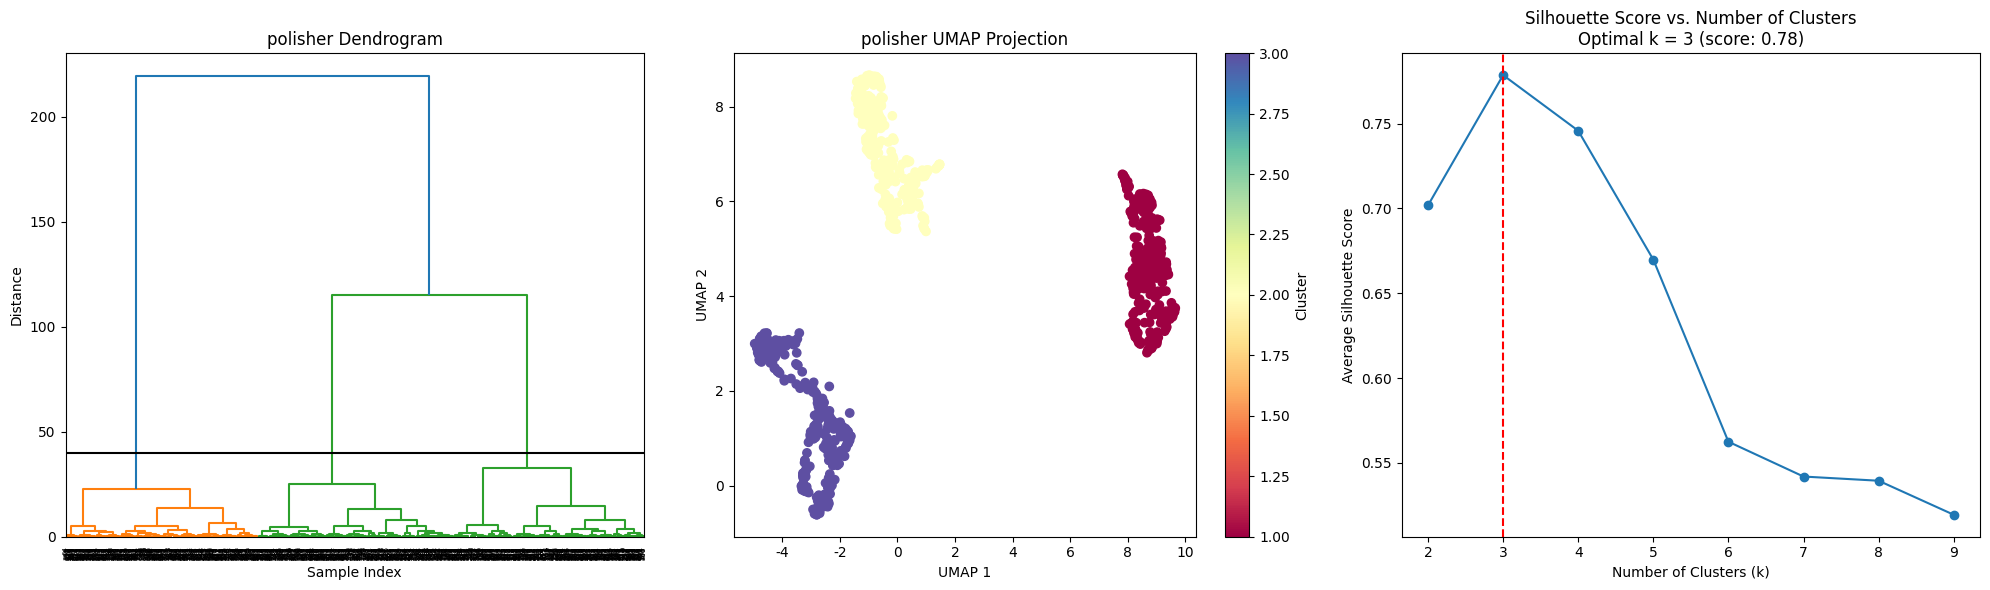

In [10]:
dend(polisher, 'polisher', 3, 40, [2, 10])

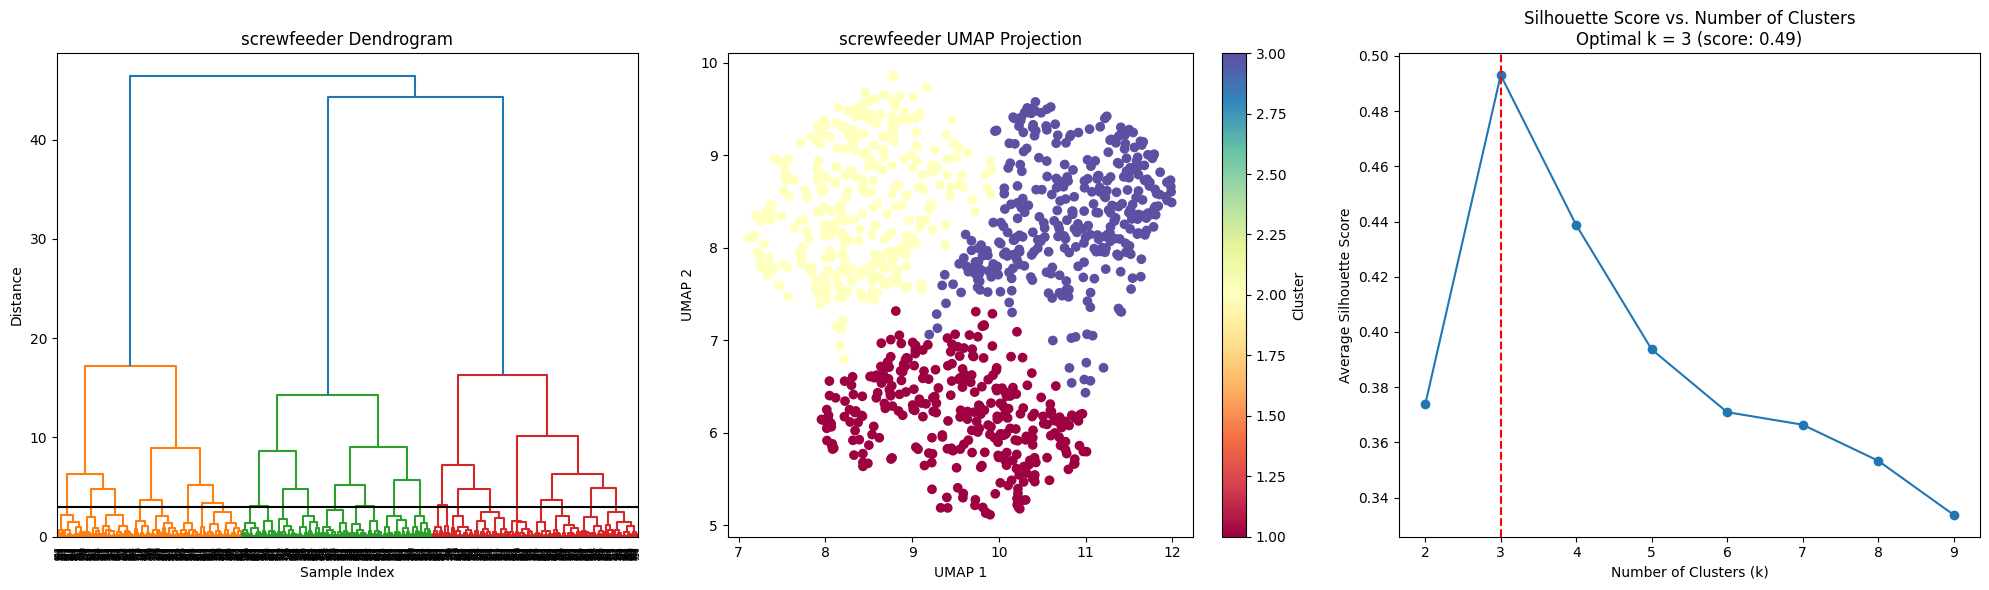

In [11]:
dend(screwfeeder, 'screwfeeder', 3, 3, [2, 10])

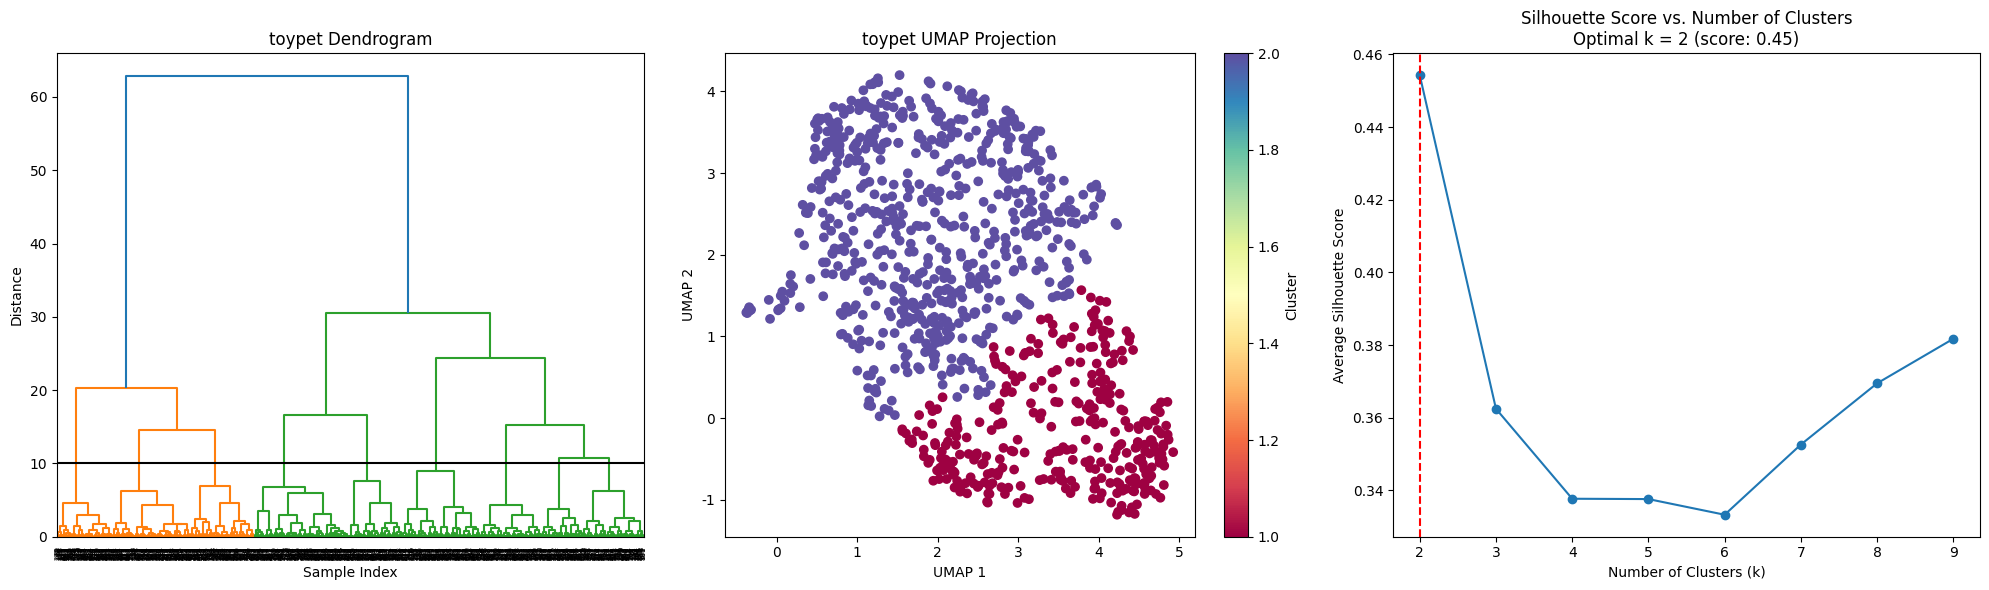

In [12]:
dend(toypet, 'toypet', 2, 10, [2, 10])